In [41]:
import numpy as np
import pandas as pd
import xarray as xr
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import cartopy.feature as cfeature
import os
from pathlib import Path

In [42]:
import requests
from datetime import datetime

def noaa_sealevel(station, start_yr, end_yr):
    """
    Downloads hourly observed water level from NOAA tide gauge.

    Parameters:
        station (int): NOAA station ID
        start_yr (int): start year
        end_yr (int): end year

    Returns:
        sl (numpy array): sea level (meters)
        md (pandas DatetimeIndex): time vector (hourly)
    """

    # ==========================
    # Create uniform hourly time base
    # ==========================
    md = pd.date_range(
        start=f"{start_yr}-01-01 00:00:00",
        end=f"{end_yr}-12-31 23:00:00",
        freq="h"
    )

    mdi_list = []
    sli_list = []

    # ==========================
    # Loop over years
    # ==========================
    for yr in range(start_yr, end_yr + 1):
        url = (
            "https://api.tidesandcurrents.noaa.gov/api/prod/datagetter"
            f"?product=hourly_height"
            f"&application=NOS.COOPS.TAC.WL"
            f"&begin_date={yr}0101"
            f"&end_date={yr}1231"
            f"&datum=NAVD"
            f"&station={station}"
            f"&time_zone=GMT"
            f"&units=metric"
            f"&format=csv"
        )

        try:
            df = pd.read_csv(url)

            # NOAA CSV usually has columns: Date Time, Water Level, etc.
            df.columns = df.columns.str.strip()

            time_col = df.columns[0]
            sl_col = df.columns[1]

            mdi = pd.to_datetime(df[time_col], errors='coerce')
            sli = pd.to_numeric(df[sl_col], errors='coerce')

            mdi_list.append(mdi)
            sli_list.append(sli)

        except Exception as e:
            print(f"Failed for year {yr}: {e}")

    # ==========================
    # Combine all years
    # ==========================
    if len(sli_list) > 0:
        mdi_all = pd.concat(mdi_list).reset_index(drop=True)
        sli_all = pd.concat(sli_list).reset_index(drop=True)

        # Create empty series aligned to full time base
        sl_series = pd.Series(index=md, dtype=float)

        # Insert values
        sl_series.loc[mdi_all] = sli_all.values

        sl = sl_series.values

        print("md: datetime index (GMT); sl: sea level (meters)")

    else:
        sl = np.full(len(md), np.nan)
        print("No data retrieved.")

    return sl, md

In [43]:
## downloading the data from https://tidesandcurrents.noaa.gov/ using api
## Here the data downloaded at NAVD datum.
## The SWOT data is WGS 84 ellipsoid.
## We will be converting the the TG which is NADV datum to WGS84 which is the reference ellipsoid for the SWOT data
## The conversion can done using the vdatum tool.://vdatum.noaa.gov/vdatumweb/vdatumweb?a=180802620260514
## The datum_corr is correction factor which will applied to TG.
## This makes both data in same reference and we can compare

station = 8447930  ## station id of woodhole tg
t0 = 2023 
tf = 2025
datum_corr = 30.212

sl, time = noaa_sealevel(station, t0, tf)
sl = sl - datum_corr
df_tg = pd.DataFrame({'time': pd.to_datetime(time),'sea_level': sl})#, #index=pd.to_datetime(time))
df_tg

md: datetime index (GMT); sl: sea level (meters)


,time,sea_level
0,2023-01-01 00:00:00,-30.215
1,2023-01-01 01:00:00,-30.274
2,2023-01-01 02:00:00,-30.322
3,2023-01-01 03:00:00,-30.346
4,2023-01-01 04:00:00,-30.344
...,...,...
26299,2025-12-31 19:00:00,-30.467
26300,2025-12-31 20:00:00,-30.306
26301,2025-12-31 21:00:00,-30.093
26302,2025-12-31 22:00:00,-29.965


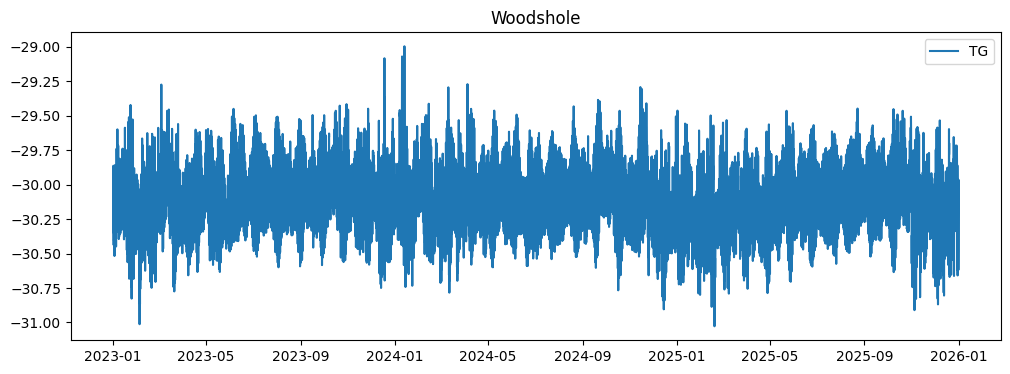

In [44]:
### plot the tg data 
## Here we are plotting the sea level after removing the mean
plt.figure(figsize=(12, 4))
plt.plot(df_tg['time'],df_tg['sea_level'],label='TG')
plt.title('Woodshole')
plt.legend()


In [45]:
## Loading the swot data

path = '/Users/anupn/Desktop/summer_school/swot_data/expert/'
  # dont forget to change this to your local one
files = sorted(os.listdir(path))
all_files = [os.path.join(path, f) for f in files]

In [46]:
## TG location 
lat_tg = 41.31
lon_tg = -70.40 + 360  # SWOT convention

## Zoomed bounding boxes for the region aroung TG
lon_min = -73
lon_max=-68
lat_min=40
lat_max= 45

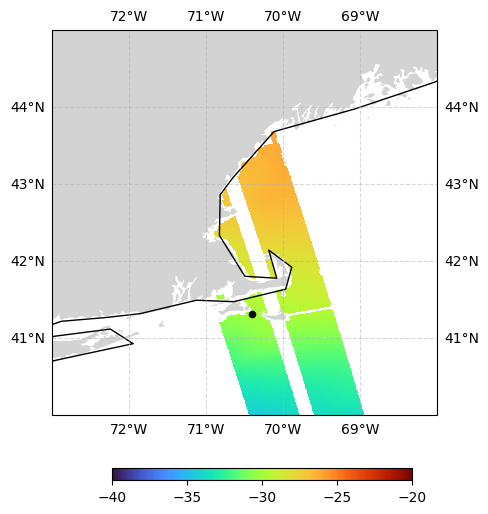

In [ ]:
ds = xr.open_dataset(all_files[1])
fig, ax = plt.subplots(1, 1,figsize=(10, 5),subplot_kw=dict(projection=ccrs.PlateCarree()))
twl = ds.ssha_unfiltered + ds.ocean_tide + ds.dac + ds.mss
pcm = ax.pcolormesh(ds.longitude,ds.latitude,twl,cmap="turbo",vmin=-40,vmax=-20, transform=ccrs.PlateCarree())
ax.coastlines(resolution="110m", linewidth=1)
ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=0)
ax.gridlines(draw_labels=True, linestyle="--", alpha=0.5)
ax.scatter(lon_tg,lat_tg,s=20,color='black',transform=ccrs.PlateCarree(),label='Tide Gauge Location')

# --- Region of interest ---
ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
cax = fig.add_axes([0.38, -0.02, 0.3, 0.025])  # [left, bottom, width, height]

cb = fig.colorbar(pcm, cax=cax,orientation="horizontal")

In [ ]:
# code that extracts the swot ssha nearest to TG
#Tide gauges measure total water level (TWL), that is, it includes tides and atmospheric effects to it. 
#So to compare SWOT data to tide gauge, we need to re-add tides and DAC  to it, as well as the mean sea-surface height

times = []
ssh_series = []
lat_series = []
lon_series = []

for f in all_files:
    try:
        ds = xr.open_dataset(f)

        lat = ds.latitude
        lon = ds.longitude
        ssh = ds.ssha_unedited +  ds.ocean_tide + ds.dac + ds.mss + ds.internal_tide
        time = ds.time

        # Mask valid data
        valid = np.isfinite(ssh)

        # Distance
        dist = (lat - lat_tg)**2 + (lon - lon_tg)**2
        dist = dist.where(valid)

        # Skip if all NaN (no valid data in pass)
        if dist.isnull().all():
            continue

        # Nearest point
        idx = dist.argmin(dim=("num_lines", "num_pixels"))

        ssh_val = ssh.isel(idx).values
        lat_val = lat.isel(idx).values
        lon_val = lon.isel(idx).values

        # Time handling (take mean if multiple)
        time_val = pd.to_datetime(time.values).mean()

        # Store
        times.append(time_val)
        ssh_series.append(ssh_val)
        lat_series.append(lat_val)
        lon_series.append(lon_val)

    except Exception as e:
        print(f"Skipping {f}: {e}")

# Convert to DataFrame
df_swot = pd.DataFrame({"swot_time": times,"swot_ssh": ssh_series,"swot_lat": lat_series,"swot_lon": lon_series})

# Sort by time
df_swot = df_swot.sort_values("swot_time")

print(df_swot.head())

                      swot_time             swot_ssh   swot_lat    swot_lon
0 2023-07-30 20:38:44.613064448             -29.6942  41.315006  289.593152
1 2023-08-20 17:23:49.975595264             -30.0474  41.315006  289.593152
2 2023-09-10 14:08:56.106344704  -30.267500000000002  41.315006  289.593152
3 2023-10-01 10:53:58.723261952             -29.9509  41.315006  289.593152
4 2023-10-22 07:39:03.108334336             -30.0092  41.315006  289.593152


In [64]:
## Interpolate tg data into nearest swot timestep
df_tg['time'] = pd.to_datetime(df_tg['time'])
df_swot['swot_time'] = pd.to_datetime(df_swot['swot_time'])

df_tg2 = df_tg.set_index('time')

# Match nearest TG value to SWOT times
df_tg_interp = df_tg2.reindex(
    df_swot['swot_time'],
    method='nearest',
    tolerance='1h'
)

print(df_tg_interp.head())

                               sea_level
swot_time                               
2023-07-30 20:38:44.613064448    -29.826
2023-08-20 17:23:49.975595264    -30.013
2023-09-10 14:08:56.106344704    -30.229
2023-10-01 10:53:58.723261952    -30.067
2023-10-22 07:39:03.108334336    -30.106


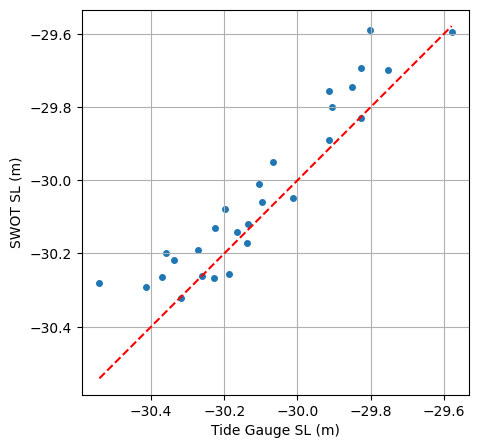

In [67]:
## Comparison
x = df_tg_interp['sea_level']
y = df_swot['swot_ssh']

plt.figure(figsize=(5,5))
plt.scatter(x, y,s=16)
plt.ylabel('SWOT SL (m)')
plt.xlabel('Tide Gauge SL (m)')
mn = np.nanmin([x.min(), y.min()])
mx = np.nanmax([x.max(), y.max()])

plt.xlim(mn, mx)
plt.ylim(mn, mx)
plt.axis('equal')
plt.plot([mn, mx],[mn, mx],'r--',label='1:1 Line')
plt.grid(True)

plt.show()

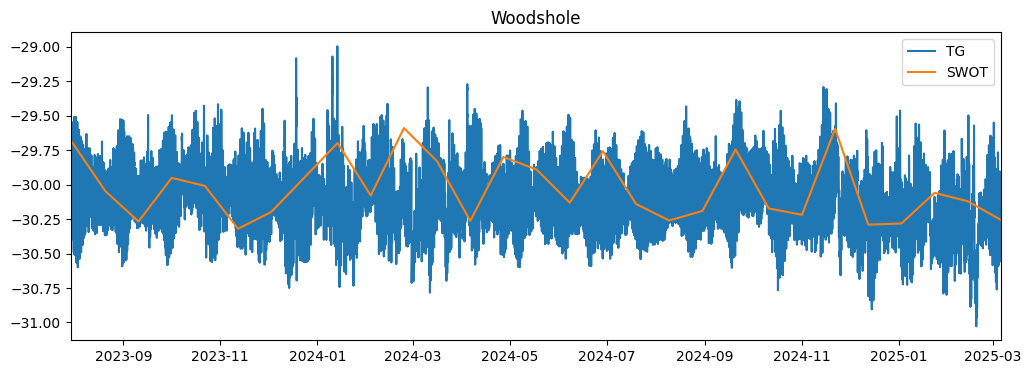

In [66]:

# plot
## Here we are plotting the sea level from TF and swot
plt.figure(figsize=(12, 4))
plt.plot(df_tg['time'],df_tg['sea_level'],label='TG')
plt.title('Woodshole')
plt.legend()
plt.plot(df_swot['swot_time'],df_swot['swot_ssh'],label='SWOT')
plt.xlim(np.datetime64('2023-07-30'),np.datetime64('2025-03-06'))
plt.legend()
plt.show()